# 1. Signal Processing

## 1.0. Libraries and Functions

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# Import all the generic functions
from PEPV_Signal_Helper_Function import (
    load_and_preprocess_data,
    detect_cycles_sinusoidal, 
    detect_cycle_phases,
    Savitzky_Golay_filter,
    signal_cycles,
    custom_sigmoid_function,
    fit_custom_sigmoid_to_cycle,
    fit_sigmoid_to_all_cycles,
    create_comprehensive_cycle_dataset,
    plot_single_signal_with_cycles,
    plot_single_signal_with_sigmoid_fits
)

## 1.1. Load Sensor Data

In [2]:
# Dataset configuration
DATA_FILES = {
    "2-Roller Pump": "Data/viscosity_sensor_calibration/roller2_dataset.csv",
    "3-Roller Pump": "Data/viscosity_sensor_calibration/roller3_dataset.csv", 
    "4-Roller Pump": "Data/viscosity_sensor_calibration/roller4_dataset.csv"
}

# Liquid metadata for visualization
LIQUIDS_INFO = {
    'CF955_flow_ml_min': {'name': 'CF955', 'viscosity': '1 cP'},
    'F50_flow_ml_min': {'name': 'F50', 'viscosity': '50 cP'},
    'F100_flow_ml_min': {'name': 'F100', 'viscosity': '100 cP'},
    'F200_flow_ml_min': {'name': 'F200', 'viscosity': '200 cP'},
    'F350_flow_ml_min': {'name': 'F350', 'viscosity': '350 cP'},
    'F500_flow_ml_min': {'name': 'F500', 'viscosity': '500 cP'},
    'F1000_flow_ml_min': {'name': 'F1000', 'viscosity': '1000 cP'},
    'F5000_flow_ml_min': {'name': 'F5000', 'viscosity': '5000 cP'},
    'F12500_flow_ml_min': {'name': 'F12500', 'viscosity': '12500 cP'}
}

# Load all datasets
datasets = {}
for name, file_path in DATA_FILES.items():
    datasets[name] = load_and_preprocess_data(file_path, name)

## 1.2. Cycle Detection

In [3]:
cycles = signal_cycles(datasets)

Overall success: 27/27 (100.0%)
Total cycles detected: 229


Total individual signals to plot: 27


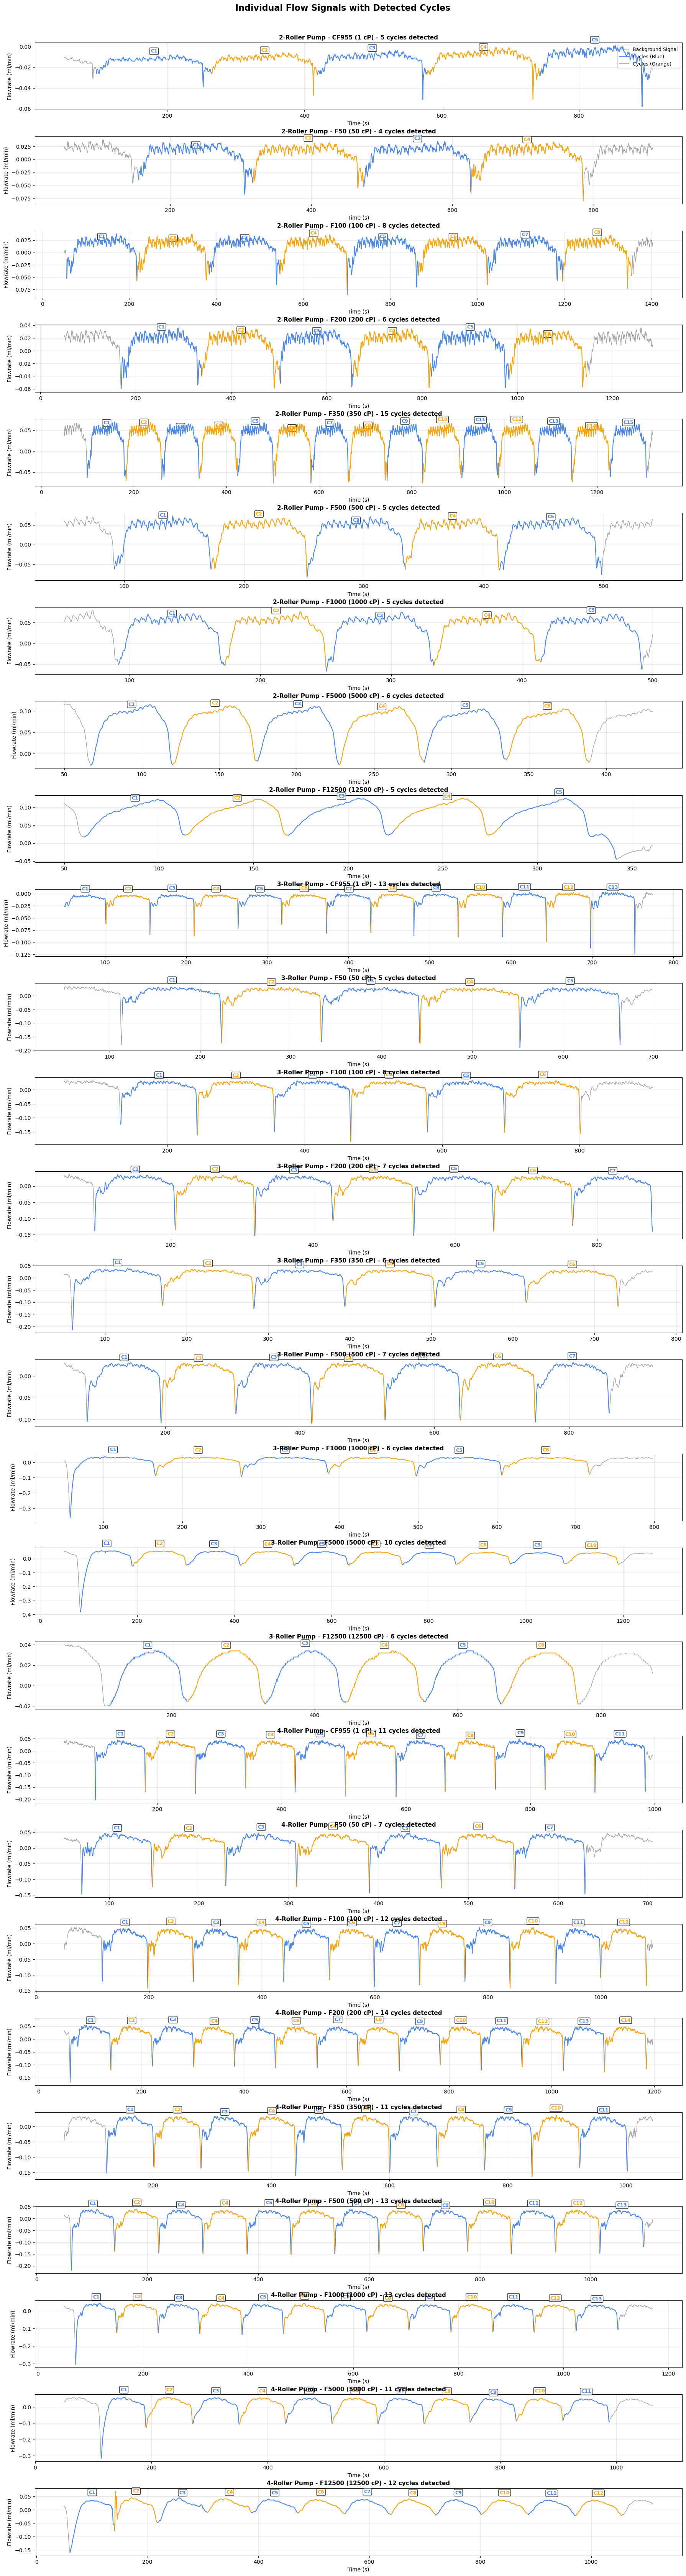

In [4]:
# Visualize every individual signal (column) from each dataset as a separate row
liquid_types = list(LIQUIDS_INFO.keys())
pump_types = list(datasets.keys())

# Create list of all individual signals
all_signals = []
for pump_type in pump_types:
    for liquid_type in liquid_types:
        if liquid_type in datasets[pump_type].columns:
            all_signals.append({
                'pump_type': pump_type,
                'liquid_type': liquid_type,
                'pump_short': pump_type.split('-')[0] + 'R',  # e.g., "2R", "3R", "4R"
                'liquid_name': liquid_type.replace('_flow_ml_min', ''),
                'display_name': f"{pump_type} - {LIQUIDS_INFO[liquid_type]['name']} ({LIQUIDS_INFO[liquid_type]['viscosity']})"
            })

num_signals = len(all_signals)
print(f"Total individual signals to plot: {num_signals}")

# Create subplot layout: one row per individual signal
fig, axes = plt.subplots(num_signals, 1, figsize=(18, 2.5 * num_signals))
fig.suptitle('Individual Flow Signals with Detected Cycles', fontsize=16, fontweight='bold', y=0.995)

# Ensure axes is always a list for consistent indexing
if num_signals == 1:
    axes = [axes]

# Use the visualization function for each signal
summary_data = []
for idx, signal_info in enumerate(all_signals):
    ax = axes[idx]
    
    pump_type = signal_info['pump_type']
    liquid_type = signal_info['liquid_type']
    
    # Get the pump data for this signal
    pump_data = datasets[pump_type]
    
    # Get liquid info from LIQUIDS_INFO
    liquid_info = LIQUIDS_INFO[liquid_type]
    
    # Extract liquid name for cycles data (generic approach)
    liquid_name = liquid_type.replace('_flow_ml_min', '')
    
    # Use the visualization function
    show_legend = (idx == 0)  # Show legend only on first subplot
    total_cycles = plot_single_signal_with_cycles(
        ax, pump_data, liquid_type, liquid_name, cycles, pump_type, liquid_info, show_legend
    )
    avg_duration = 0
    avg_amplitude = 0
    
    if (pump_type in cycles['datasets'] and 
        'liquid_results' in cycles['datasets'][pump_type] and 
        liquid_name in cycles['datasets'][pump_type]['liquid_results']):
        
        liquid_results_info = cycles['datasets'][pump_type]['liquid_results'][liquid_name]
        if 'avg_duration' in liquid_results_info:
            avg_duration = liquid_results_info['avg_duration']
        if 'avg_amplitude' in liquid_results_info:
            avg_amplitude = liquid_results_info['avg_amplitude']
    
    summary_data.append({
        'pump_type': pump_type,
        'liquid_name': liquid_info['name'],
        'viscosity': liquid_info['viscosity'],
        'cycles': total_cycles,
        'avg_duration': avg_duration,
        'avg_amplitude': avg_amplitude
    })

# Adjust layout to prevent overlap
plt.tight_layout()
plt.subplots_adjust(top=0.98, hspace=0.4)
plt.show()

## 1.3. Sigmoid Fitting

In [5]:
sigmoid_fit = fit_sigmoid_to_all_cycles(cycles)

c:\Users\mrast\OneDrive\Documents\GitHub\Pump_Viscometer_PEPV\PEPV_Signal_Helper_Function.py:594: RuntimeWarning: overflow encountered in exp
  term4 = h4 / (1 + np.exp(-(x - a4) / b4))


   ✅ Success on attempt 2: R²=0.917, constraints satisfied
   ✅ Success on attempt 2: R²=0.886, constraints satisfied
   ✅ Success on attempt 2: R²=0.895, constraints satisfied
   ✅ Success on attempt 2: R²=0.921, constraints satisfied
   ✅ Success on attempt 2: R²=0.922, constraints satisfied
   ✅ Success on attempt 2: R²=0.978, constraints satisfied
   ✅ Success on attempt 3: R²=0.955, constraints satisfied
   ✅ Success on attempt 4: R²=0.979, constraints satisfied


c:\Users\mrast\OneDrive\Documents\GitHub\Pump_Viscometer_PEPV\PEPV_Signal_Helper_Function.py:593: RuntimeWarning: overflow encountered in exp
  term3 = h3 / (1 + np.exp(-(x - a3) / b3))


   ✅ Success on attempt 3: R²=0.974, constraints satisfied
   ✅ Success on attempt 2: R²=0.985, constraints satisfied
   ✅ Success on attempt 2: R²=0.990, constraints satisfied
   ✅ Success on attempt 2: R²=0.971, constraints satisfied
   ✅ Success on attempt 2: R²=0.987, constraints satisfied
   ✅ Success on attempt 2: R²=0.993, constraints satisfied
   ✅ Success on attempt 2: R²=0.999, constraints satisfied
   ✅ Success on attempt 2: R²=0.963, constraints satisfied
   ✅ Success on attempt 2: R²=0.991, constraints satisfied
   ✅ Success on attempt 2: R²=0.990, constraints satisfied
   ✅ Success on attempt 2: R²=0.993, constraints satisfied
   ✅ Success on attempt 2: R²=0.998, constraints satisfied
   📈 Overall success rate: 100.0%


Total individual signals to plot with sigmoid fits: 27


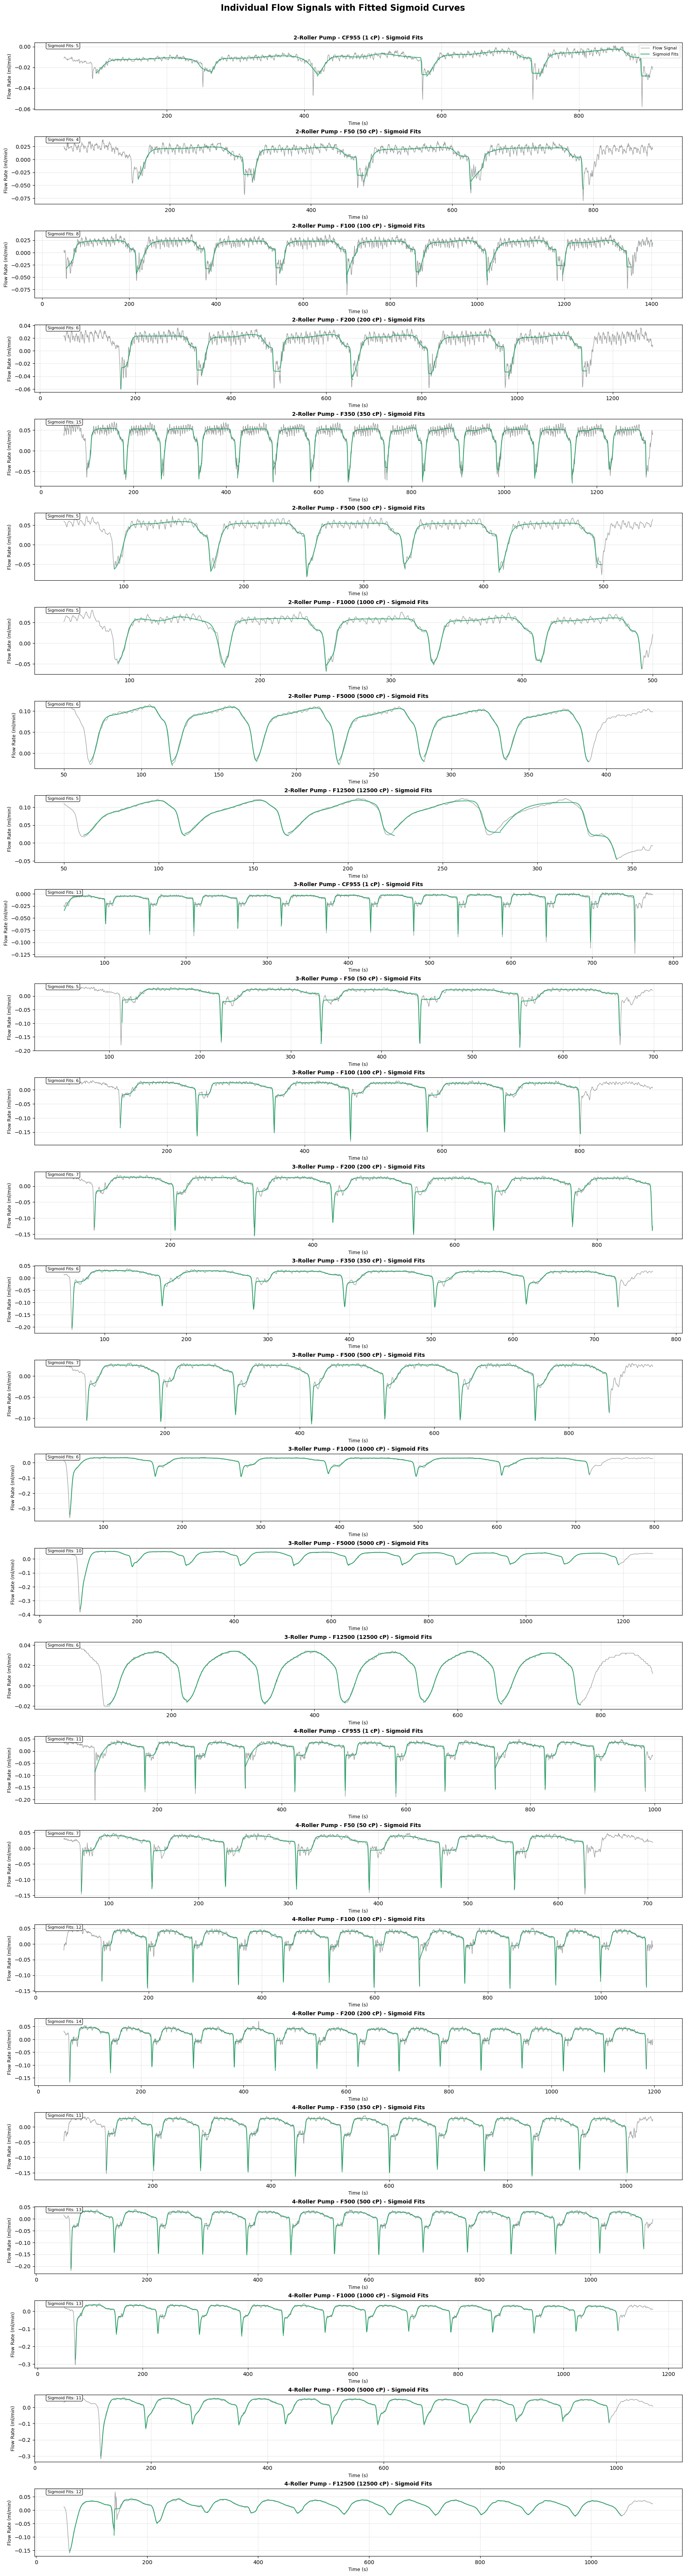

In [6]:
# Visualize sigmoid fits for all individual signals
liquid_types = list(LIQUIDS_INFO.keys())
pump_types = list(datasets.keys())

# Create list of all individual signals (reusing the same structure)
all_signals = []
for pump_type in pump_types:
    for liquid_type in liquid_types:
        if liquid_type in datasets[pump_type].columns:
            all_signals.append({
                'pump_type': pump_type,
                'liquid_type': liquid_type,
                'pump_short': pump_type.split('-')[0] + 'R',  # e.g., "2R", "3R", "4R"
                'liquid_name': liquid_type.replace('_flow_ml_min', ''),
                'display_name': f"{pump_type} - {LIQUIDS_INFO[liquid_type]['name']} ({LIQUIDS_INFO[liquid_type]['viscosity']})"
            })

num_signals = len(all_signals)
print(f"Total individual signals to plot with sigmoid fits: {num_signals}")

# Create subplot layout: one row per individual signal
fig, axes = plt.subplots(num_signals, 1, figsize=(18, 2.5 * num_signals))
fig.suptitle('Individual Flow Signals with Fitted Sigmoid Curves', fontsize=16, fontweight='bold', y=0.995)

# Ensure axes is always a list for consistent indexing
if num_signals == 1:
    axes = [axes]

# Use the sigmoid visualization function for each signal
sigmoid_summary_data = []
for idx, signal_info in enumerate(all_signals):
    ax = axes[idx]
    
    pump_type = signal_info['pump_type']
    liquid_type = signal_info['liquid_type']
    
    # Get the pump data for this signal
    pump_data = datasets[pump_type]
    
    # Get liquid info from LIQUIDS_INFO
    liquid_info = LIQUIDS_INFO[liquid_type]
    
    # Extract liquid name for cycles data (generic approach)
    liquid_name = liquid_type.replace('_flow_ml_min', '')
    
    # Use the sigmoid visualization function
    show_legend = (idx == 0)  # Show legend only on first subplot
    sigmoid_fits_count = plot_single_signal_with_sigmoid_fits(
        ax, pump_data, liquid_type, liquid_name, cycles, sigmoid_fit, pump_type, liquid_info, show_legend
    )
    
    # Collect summary data
    sigmoid_summary_data.append({
        'pump_type': pump_type,
        'liquid_name': liquid_info['name'],
        'viscosity': liquid_info['viscosity'],
        'sigmoid_fits': sigmoid_fits_count
    })

# Adjust layout to prevent overlap
plt.tight_layout()
plt.subplots_adjust(top=0.98, hspace=0.4)
plt.show()

## 1.4. Create Cycles Dataset

In [7]:
df = create_comprehensive_cycle_dataset(cycles, sigmoid_fit, LIQUIDS_INFO)


📊 DATASET CREATION SUMMARY:
   🎯 Total cycles: 229
   📈 Unique samples: 9
All cycles have sigmoid fits


In [8]:
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (229, 19)


,sample_name,pump_rollers,cycle_number,a1,a2,a3,a4,h1,h2,h3,h4,b1,b2,b3,b4,duration_sec,flow_max_ml_min,flow_min_ml_min,viscosity_cp
0,CF955,4,1,0.044103,0.499,0.895833,0.916863,0.529084,0.061314,-0.185044,-0.317874,0.032927,0.048497,0.011117,0.064110,167.5,-0.008,-0.039,1.0
1,CF955,4,2,0.020547,0.499,0.500000,0.988812,0.492821,0.288183,-0.226664,-0.804902,0.024393,0.089760,0.099000,0.059258,154.5,-0.006,-0.047,1.0
2,CF955,4,3,0.043645,0.499,0.508444,0.951168,0.583134,0.918220,-0.990000,-0.350381,0.039589,0.077029,0.099000,0.001603,159.5,-0.004,-0.051,1.0
3,CF955,4,4,0.047803,0.499,0.807495,0.927957,0.524946,0.066178,-0.134918,-0.292174,0.035506,0.054386,0.022217,0.001349,164.5,-0.001,-0.051,1.0
4,CF955,4,5,0.028605,0.499,0.792104,0.923815,0.527557,0.073170,-0.143514,-0.302878,0.029926,0.093079,0.019447,0.001418,159.5,0.001,-0.058,1.0


## 1.5. Save Dataset

In [9]:
# Create Data directory if it doesn't exist
data_dir = "Data"
os.makedirs(data_dir, exist_ok=True)

# Save the comprehensive cycle dataset as CSV
csv_filename = "Silicone_cycles.csv"
csv_filepath = os.path.join(data_dir, csv_filename)

df.to_csv(csv_filepath, index=False)